# Session XIII — Reversible training of a 21M LLM

Assignment: train a ~20M model for 50M tokens at a fixed batch size, train again with reversibility
(midpoint, Euler, leapfrog, midpoint-a), then train again with reversibility at the largest batch
that fits. Report final loss, tokens/s, and peak memory.

This notebook is the walkthrough. The 50M-token runs already live in `runs/`; re-running them
from here would take a few hours on the T4. The cells below:

1. build the same 21.25M GPT and show that the reversible backward matches autograd,
2. load every finished run and plot loss, reconstruction error, memory, and throughput.

Full write-up: [README.md](README.md). Hardware: one Tesla T4, fp16, PyTorch 2.14.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
if not (ROOT / "model.py").exists() and (ROOT / "Session-XIII" / "model.py").exists():
    ROOT = ROOT / "Session-XIII"
sys.path.insert(0, str(ROOT))

from model import GPT, GPTConfig, MODES

print("cuda:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
print("modes:", MODES)


cuda: True Tesla T4
modes: ('baseline', 'midpoint', 'midpoint_a', 'leapfrog', 'euler')


## The model and the four reversible updates

Same block in every variant,

$$f(p) = \mathrm{Attn}(\mathrm{LN}_1 p) + \mathrm{MLP}(\mathrm{LN}_2(p + \mathrm{Attn}(\mathrm{LN}_1 p))).$$

Only the rule that carries state from layer to layer changes. Given the output, the inverse
rebuilds the previous state, so the backward pass does not have to store activations.

| name | forward | inverse used in backward |
|---|---|---|
| baseline | $p_{l+1} = p_l + f(p_l)$ | not invertible; activations stored |
| midpoint | $p_{l+1} = p_{l-1} + 2h\,f(p_l)$ | $p_{l-1} = p_{l+1} - 2h\,f(p_l)$ |
| midpoint_a | $p_{l+1} = a\,p_{l-1} + (1-a)\,p_l + h\,f(p_l)$ | divide the residual by $a$ |
| leapfrog | $p_{l+1} = 2p_l - p_{l-1} + h^2 f(p_l)$ | $p_{l-1} = 2p_l - p_{l+1} + h^2 f(p_l)$ |
| euler | $q \leftarrow q + \mathrm{Attn}(p)$, then $p \leftarrow p + \mathrm{MLP}(q)$ | undo MLP, then attention |

`midpoint_a` uses $a = \pm 1 + U(-\tfrac{1}{2}, \tfrac{1}{2})$, fixed per layer. In expectation that
is a normal residual step, which is why it tracks the baseline. Midpoint, leapfrog, and euler keep
their hidden states in int64 fixed point so the inverse is exact under fp16. Midpoint-a multiplies
by a non-integer $a$, so it stays in float and is only approximately reversible.


In [2]:
cfg = GPTConfig(mode="leapfrog", h=1.0)
model = GPT(cfg)
n = model.num_params()
print(f"parameters: {n/1e6:.2f}M total, {model.num_params(non_embedding=True)/1e6:.2f}M without embeddings")
print(f"layers={cfg.n_layer}  d={cfg.n_embd}  heads={cfg.n_head}  ctx={cfg.block_size}  vocab={cfg.vocab_size}")
print("exact fixed-point state:", model.exact)


parameters: 21.25M total, 17.71M without embeddings
layers=10  d=384  heads=6  ctx=1024  vocab=8192
exact fixed-point state: True


## Check: reversible backward vs plain autograd

`test_reversible.py` builds two copies of each variant. One stores activations and uses normal
autograd. The other throws the activations away and rebuilds them. The relative gradient error
should be about $10^{-6}$ in fp32.

The interesting rows are the **grown** ones (weights scaled 4×, standing in for a partly trained
model). There, float-state reversal drifts and the gradient error jumps to 15–30%. Fixed-point
state stays at the same error as ordinary fp16 autograd, and the rebuilt embedding input matches
to about $10^{-9}$.


In [3]:
import test_reversible
test_reversible.main()


init  midpoint    fp32 rev-vs-autograd 2.1e-06 | fp16 grad err vs fp32: autograd 6.95e-03, rev-float 7.07e-03, rev-fixed 6.86e-03 | recon err float 4.5e-03, fixed 8.5e-10
init  midpoint_a  fp32 rev-vs-autograd 1.5e-06 | fp16 grad err vs fp32: autograd 6.99e-03, rev-float 7.07e-03, rev-fixed 7.07e-03 | recon err float 1.8e-03, fixed 1.8e-03
init  leapfrog    fp32 rev-vs-autograd 3.9e-06 | fp16 grad err vs fp32: autograd 6.38e-03, rev-float 6.65e-03, rev-fixed 6.44e-03 | recon err float 4.5e-03, fixed 8.7e-10
init  euler       fp32 rev-vs-autograd 2.3e-06 | fp16 grad err vs fp32: autograd 7.52e-03, rev-float 7.66e-03, rev-fixed 7.31e-03 | recon err float 2.6e-03, fixed 8.4e-10
grown midpoint    fp32 rev-vs-autograd 2.2e-04 | fp16 grad err vs fp32: autograd 7.26e-02, rev-float 2.11e-01, rev-fixed 7.30e-02 | recon err float 6.4e+00, fixed 7.8e-10
grown midpoint_a  fp32 rev-vs-autograd 1.6e-04 | fp16 grad err vs fp32: autograd 7.15e-02, rev-float 1.52e-01, rev-fixed 1.52e-01 | recon err flo

## The 50M-token runs

Batch 16 × 1024 tokens was the fixed batch (16,384 tokens/step, 3,051 steps). The max-batch
runs use the largest batch that still trained, with the cross-entropy computed in chunks so the
logit tensor is not the thing that runs out of memory.

Validation loss is the full 1M-token holdout. Tokens/s is the steady rate after step 50, with
evaluation time left out.


In [4]:
runs_dir = ROOT / "runs"

def load_runs():
    out = {}
    for p in sorted(runs_dir.glob("*/summary.json")):
        s = json.loads(p.read_text())
        log = [json.loads(l) for l in (p.parent / "log.jsonl").read_text().splitlines()]
        out[s["name"]] = (s, log)
    return out

runs = load_runs()
full = {n: r for n, r in runs.items() if not n.startswith("sweep")}

header = f"{'run':<28} {'batch':>6} {'val':>7} {'train':>7} {'tok/s':>8} {'alloc GB':>8} {'min':>6}"
print(header)
print("-" * len(header))
for name, (s, _) in full.items():
    print(f"{name:<28} {s['batch']:6d} {s['final_val_loss']:7.3f} {s['final_train_loss']:7.3f} "
          f"{(s['tok_s_steady'] or s['tok_s_avg']):8.0f} {s['peak_alloc_gb']:8.2f} {s['train_time_s']/60:6.1f}")


run                           batch     val   train    tok/s alloc GB    min
----------------------------------------------------------------------------
baseline_b16                     16   3.991   3.987    77313     3.95   10.8
baseline_maxb48                  48   4.109   4.124    79745    11.25   10.4
euler_b16                        16   4.473   4.451    58977     1.92   14.2
leapfrog_b16                     16   4.113   4.113    57096     1.92   14.6
leapfrog_maxb384                384   6.331   6.331    56774    13.88   14.7
leapfrog_maxb384_lr1.2e-2       384   6.474   6.477    57324    13.88   14.6
midpoint_a_b16                   16   4.003   3.999    55511     1.85   15.0
midpoint_a_b16_autograd          16   4.012   4.007    71433     3.94   11.7
midpoint_a_maxb456              456   6.382   6.381    55443    13.07   15.0
midpoint_b16                     16   4.217   4.215    57828     1.92   14.5


## Loss at the fixed batch, and at the max batch

Solid lines are batch 16. Dashed lines are the largest batch that fit. The max-batch reversible
runs stay near 6.3 because 50M tokens at ~400k tokens/step is only about 110 optimizer steps.


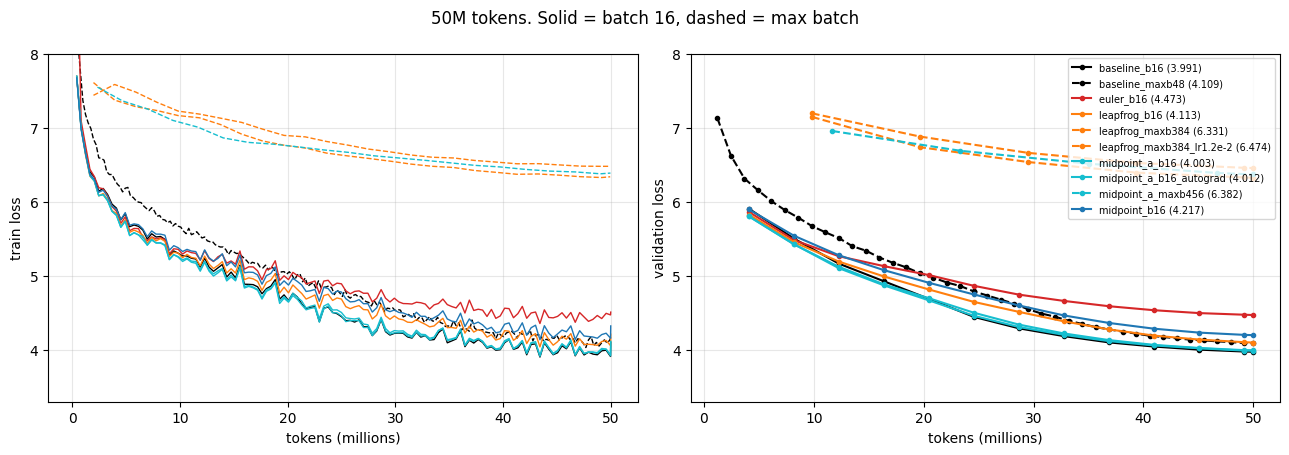

In [5]:
colors = {"baseline": "black", "midpoint": "tab:blue", "midpoint_a": "tab:cyan",
          "leapfrog": "tab:orange", "euler": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for name, (s, log) in full.items():
    c = colors.get(s["mode"])
    ls = "--" if s["batch"] > 16 else "-"
    label = f"{name} ({s['final_val_loss']:.3f})"
    axes[0].plot([r["tokens"] / 1e6 for r in log], [r["loss"] for r in log], color=c, ls=ls, lw=1, label=label)
    v = [r for r in log if "val" in r]
    axes[1].plot([r["tokens"] / 1e6 for r in v], [r["val"] for r in v], color=c, ls=ls, marker="o", ms=3, label=label)
for ax, title in zip(axes, ("train loss", "validation loss")):
    ax.set_xlabel("tokens (millions)")
    ax.set_ylabel(title)
    ax.set_ylim(3.3, 8.0)
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=7, loc="upper right")
fig.suptitle("50M tokens. Solid = batch 16, dashed = max batch")
fig.tight_layout()
plt.show()


## Why fixed-point state was necessary

Under fp16 autocast, reversing ten layers in float reconstructs an embedding input that is
several times larger than the real one after ~100 steps. The loss still decreases, so nothing
in the training log says the gradients are being computed at the wrong activation. Storing the
state as int64 fixed point (32 fractional bits) keeps the relative reconstruction error near
$10^{-9}$ for the whole run. Midpoint-a cannot use that trick, because $a$ is not $\pm 1$.


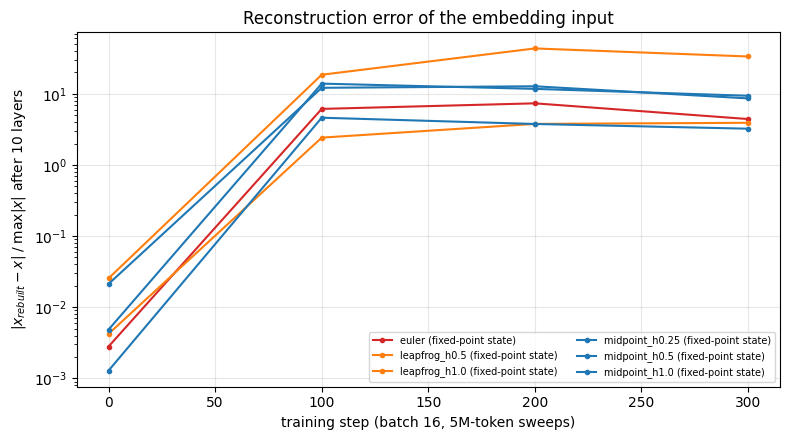

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for prefix, ls, tag in (("sweepfloat_", "--", "float state"), ("sweep_", "-", "fixed-point state")):
    for name, (s, _) in runs.items():
        if not name.startswith(prefix) or s["mode"] in ("baseline", "midpoint_a") or not s["recon_err"]:
            continue
        steps = [r[0] for r in s["recon_err"]]
        errs = [max(r[1], 1e-12) for r in s["recon_err"]]
        ax.plot(steps, errs, ls=ls, marker="o", ms=3, color=colors[s["mode"]],
                label=f"{name[len(prefix):]} ({tag})")
ax.set_yscale("log")
ax.set_xlabel("training step (batch 16, 5M-token sweeps)")
ax.set_ylabel(r"$|x_{rebuilt} - x| \;/\; \max|x|$ after 10 layers")
ax.set_title("Reconstruction error of the embedding input")
ax.grid(alpha=0.3)
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()


## Memory and speed versus batch size

Reversibility removes the per-layer activations. What is left at large batch is the logit tensor
(`tokens × 8192`), so the cross-entropy is computed in chunks of 8 sequences. With that, the
reversible max batch on this T4 is 412 (leapfrog, int64 state) or 484 (midpoint-a, float state),
against 56 for the baseline.

Throughput does not rise with batch. At 16k tokens/step the T4 is already busy, so the extra
room is for longer context or a deeper model, not for more tokens per second.


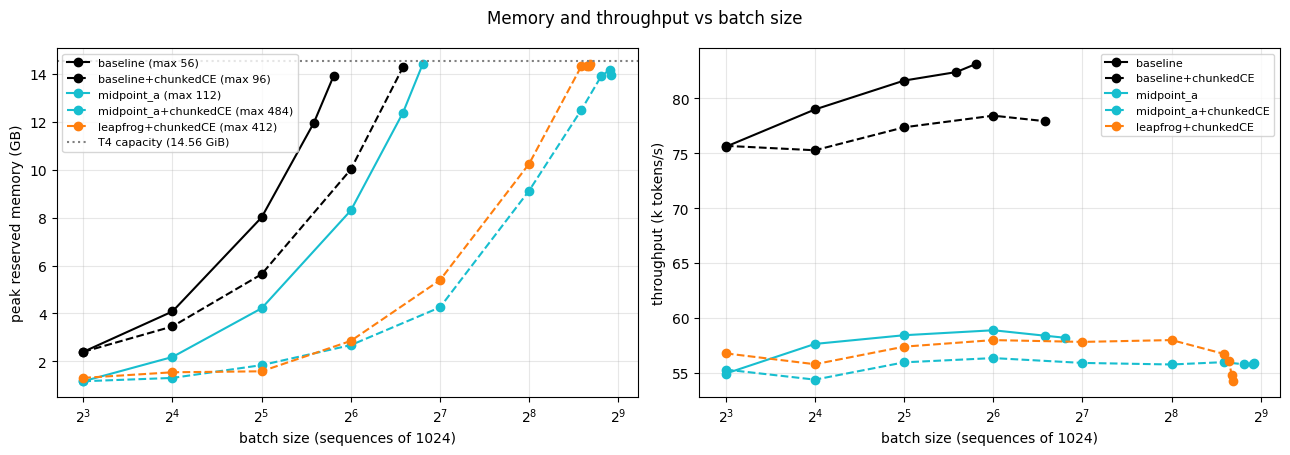

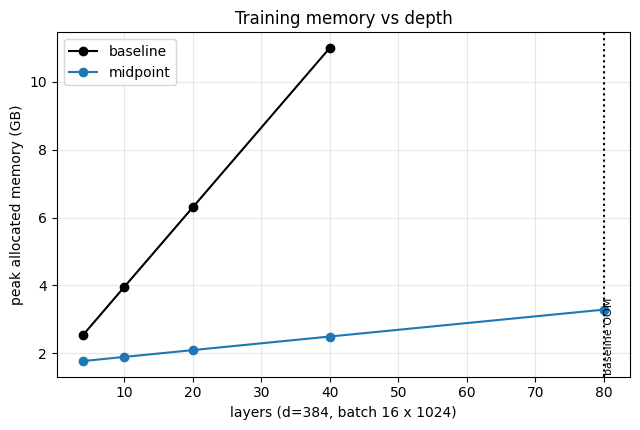

In [7]:
sweep = json.loads((ROOT / "artifacts" / "batch_sweep.json").read_text())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for key, d in sweep.items():
    mode = key.split("+")[0]
    ls = "--" if "chunked" in key else "-"
    bs = [r["batch"] for r in d["probes"]]
    axes[0].plot(bs, [r["peak_reserved_gb"] for r in d["probes"]], marker="o", ls=ls,
                 color=colors.get(mode), label=f"{key} (max {d['max_batch']})")
    axes[1].plot(bs, [r["tok_s"] / 1e3 for r in d["probes"]], marker="o", ls=ls,
                 color=colors.get(mode), label=key)
axes[0].axhline(14.56, color="gray", ls=":", label="T4 capacity (14.56 GiB)")
axes[0].set_ylabel("peak reserved memory (GB)")
axes[1].set_ylabel("throughput (k tokens/s)")
for ax in axes:
    ax.set_xscale("log", base=2)
    ax.set_xlabel("batch size (sequences of 1024)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Memory and throughput vs batch size")
fig.tight_layout()
plt.show()

depth = json.loads((ROOT / "artifacts" / "depth_probe.json").read_text())
fig, ax = plt.subplots(figsize=(6.5, 4.4))
for mode in ("baseline", "midpoint"):
    ok = [r for r in depth if r["mode"] == mode and not r["oom"]]
    ax.plot([r["n_layer"] for r in ok], [r["peak_alloc_gb"] for r in ok], marker="o",
            color=colors[mode], label=mode)
    for r in depth:
        if r["mode"] == mode and r["oom"]:
            ax.axvline(r["n_layer"], color=colors[mode], ls=":")
            ax.text(r["n_layer"], 1.2, f"  {mode} OOM", rotation=90, color=colors[mode], fontsize=8)
ax.set_xlabel("layers (d=384, batch 16 x 1024)")
ax.set_ylabel("peak allocated memory (GB)")
ax.set_title("Training memory vs depth")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## What I would report

At batch 16, **midpoint-a** is the variant that worked: validation loss 4.003 against 3.991 for the
plain residual baseline, at 1.85 GB instead of 3.95 GB, and about 28% fewer tokens/s (55.5k vs 77.3k).
Among the variants that reverse exactly in fp16, **leapfrog** is the best (4.113), then midpoint
(4.217), then the Hamiltonian / symplectic Euler coupling (4.473). That order matches the lecture:
midpoint beats Euler.

Pushing the batch is a memory result, not a loss result. Leapfrog trains at batch **384** (13.9 GB)
and midpoint-a at batch **456** (13.1 GB), versus batch **56** for the baseline before it runs out
of memory. At a fixed 50M tokens those huge steps only get ~110 updates, so the loss stays near 6.3.
The baseline's own max batch of 48 already costs 0.12 val loss (4.109 vs 3.991) for almost no
speedup (79.7k vs 77.3k tokens/s).

The part I did not expect: a reversible backward written in fp32, on top of fp16 matmuls, looks
correct at step 0 and is badly wrong by step 100. Fixed-point hidden state is what makes the
inverse actually exact.
